# Exploratory Analysis

## tl;dr
The 50-possession sample contains 430 comparison cores after lagged-profile eligibility.

## Context & Methods
A core must retain at least two fifth players after each filter. All exposure totals are calculated on unique lineup keys.

### Key Assumptions
Regular-season PBP Stats aggregates; lagged profiles; observational comparisons. See [methodology](../docs/methodology_notes.md).

## Data
Run the cached pipeline and offline analysis before this notebook. No network requests are made here.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from IPython.display import display, Image, Markdown
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'data_pipeline.py').exists())
DATA = ROOT / 'data' / 'processed'
import sys
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
pd.set_option('display.max_columns', 12)


## Results

### Before and after feature eligibility

In [2]:
display(pd.read_csv(DATA/'thresholds_before_profiles.csv'))
display(pd.read_csv(DATA/'thresholds_after_profiles.csv'))

,threshold,eligible_lineups,eligible_core_rows,comparison_cores,comparison_rows,comparison_lineups,comparison_mean_side_possessions
0,0,15663,78315,18927,67509,15636,244023.0
1,10,5307,26535,6458,18936,5214,196607.0
2,25,1911,9555,2204,5805,1865,143450.5
3,50,736,3680,759,1847,689,101025.5
4,100,290,1450,265,601,265,69950.5
5,200,101,505,62,132,86,40787.0


,threshold,eligible_lineups,eligible_core_rows,comparison_cores,comparison_rows,comparison_lineups,comparison_mean_side_possessions
0,0,4602,23010,5961,20319,4596,100099.0
1,10,1830,9150,2392,6806,1815,87422.5
2,25,804,4020,978,2558,787,70728.0
3,50,376,1880,430,1018,358,54956.5
4,100,156,780,143,320,142,39107.0
5,200,60,300,39,81,54,24909.0


### Exposure distribution

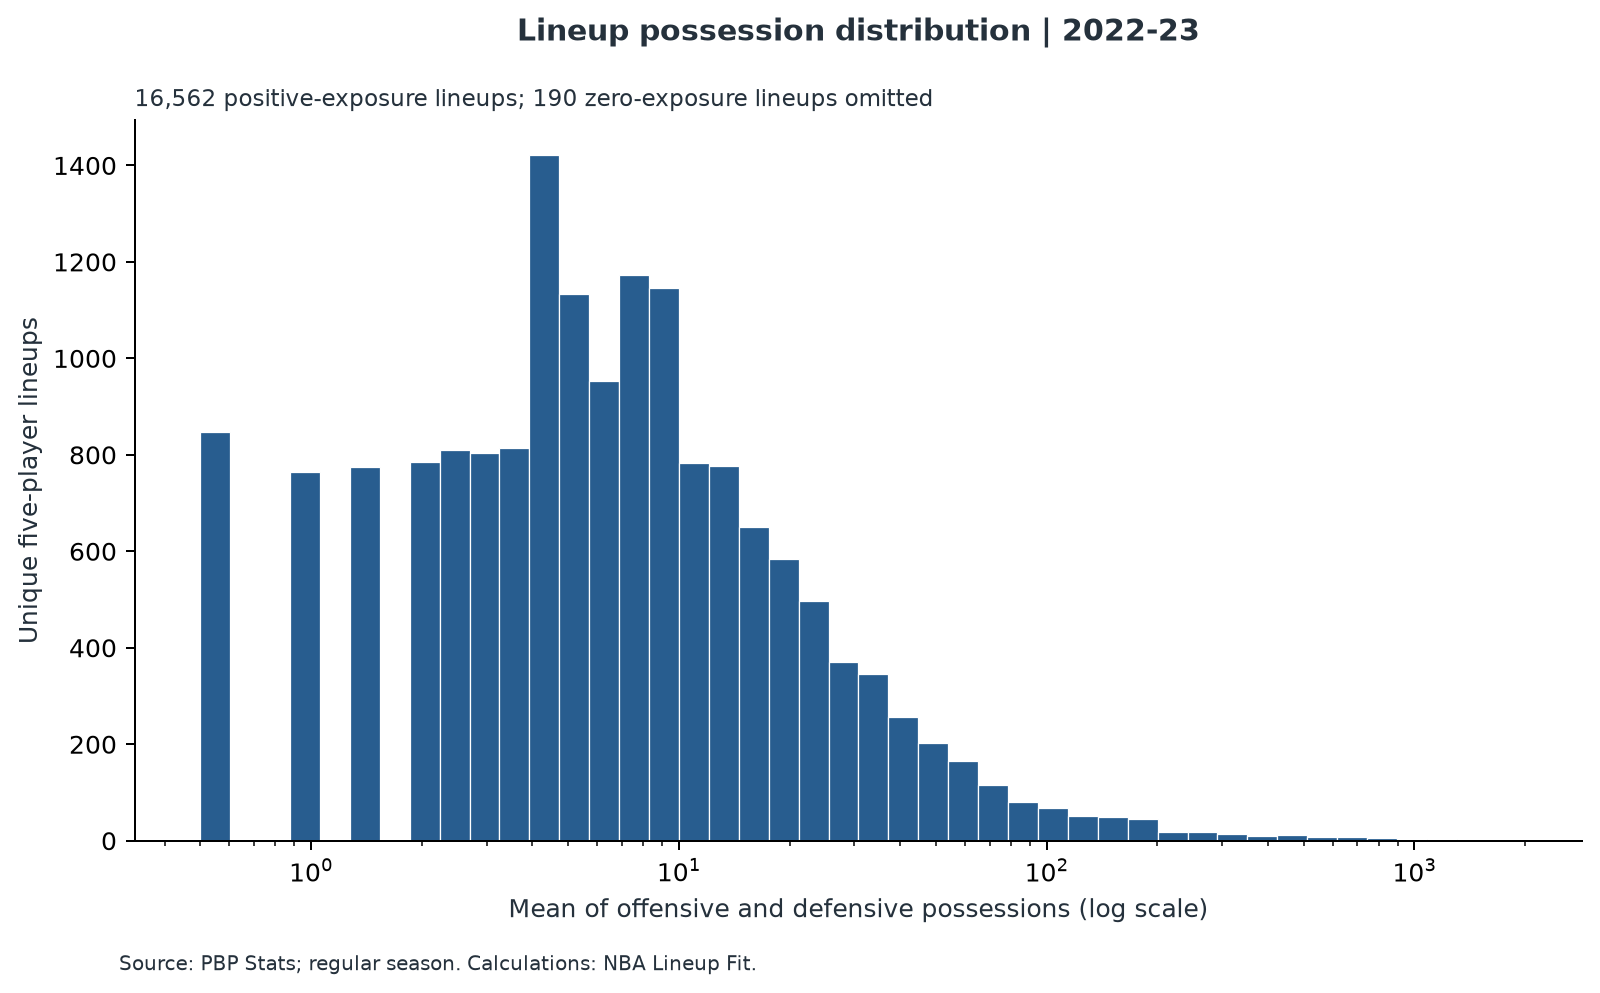

In [3]:
display(Image(filename=str(ROOT/'figures'/'possession_distribution.png')))

### Threshold tradeoff

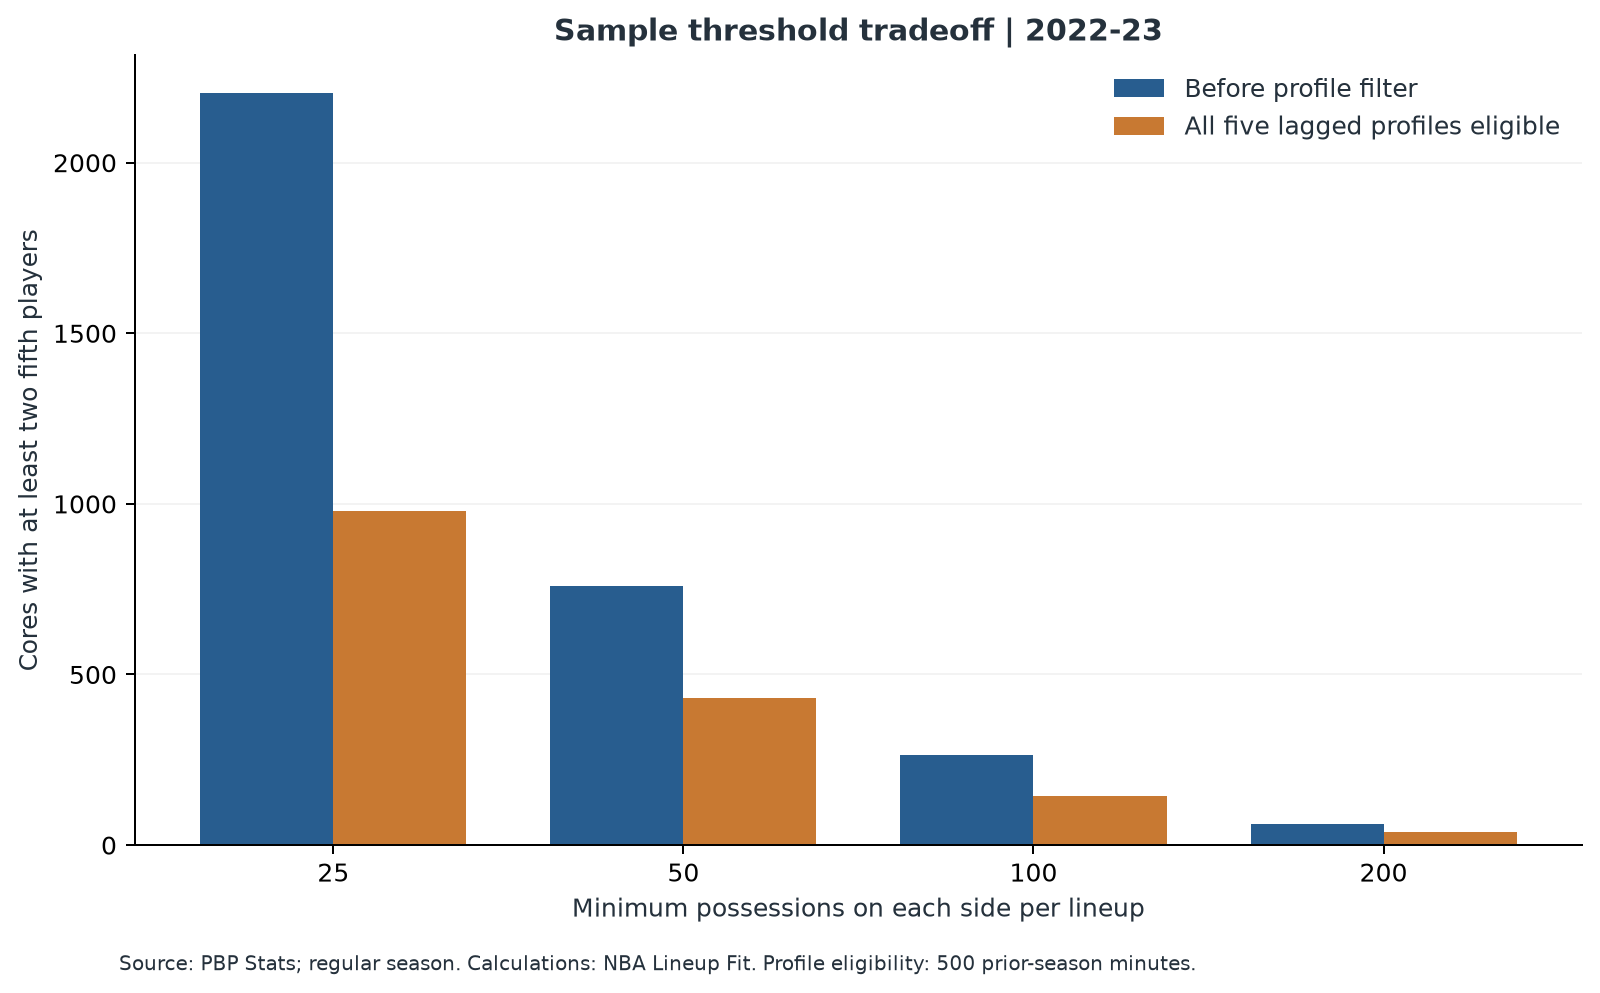

In [4]:
display(Image(filename=str(ROOT/'figures'/'threshold_tradeoff.png')))

### Where comparison variation is available

In [5]:
teams=pd.read_csv(DATA/'team_comparison_coverage.csv')
display(teams.groupby('season')[['cores','core_rows','lineups']].sum())
display(teams.sort_values('cores',ascending=False).head(10))

,cores,core_rows,lineups
season,,,
2022-23,430,1018,358


,season,team_id,team,core_rows,cores,lineups
13,2022-23,1610612752,NYK,89,37,29
1,2022-23,1610612738,BOS,81,32,21
2,2022-23,1610612739,CLE,83,31,27
22,2022-23,1610612764,WAS,72,30,23
5,2022-23,1610612742,DAL,66,29,25
14,2022-23,1610612755,PHI,68,29,22
8,2022-23,1610612747,LAL,57,26,20
6,2022-23,1610612744,GSW,56,24,18
0,2022-23,1610612737,ATL,52,22,16
11,2022-23,1610612750,MIN,49,21,19


### Independent SQL audit

In [6]:
import sqlite3
with sqlite3.connect(DATA/'analysis.sqlite') as conn:
    display(pd.read_sql_query((ROOT/'sql'/'analysis_queries.sql').read_text(),conn))

,threshold,comparison_cores,comparison_rows
0,25,978,2558
1,50,430,1018
2,100,143,320
3,200,39,81


## Takeaways
Thresholds change the population being studied. A higher threshold reduces sampling noise but does not eliminate selection bias. Do not count expanded rows as independent observations.